--- Data Loading and Initial Preprocessing ---
Common prefixes found: ['LDAP', 'Syn', 'UDPLag', 'MSSQL', 'UDP', 'NetBIOS']
Loading 6 training files and 6 testing files...
Data loaded.
Initial Training data shape: (120065, 78)
Initial Testing data shape: (38973, 78)
Dropped 'WebDDoS' label from testing data.
Dropped 'NetBIOS' and 'UDPLag' labels.

--- Feature Engineering & Further Preprocessing ---
Dropped 12 single-value columns from train data: ['Bwd PSH Flags', 'Fwd URG Flags', 'Fwd Avg Bulk Rate', 'Bwd Avg Packets/Bulk', 'Bwd URG Flags', 'Bwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'ECE Flag Count', 'Fwd Avg Packets/Bulk', 'FIN Flag Count', 'PSH Flag Count', 'Bwd Avg Bytes/Bulk']
Dropped 12 single-value columns from test data: ['Bwd PSH Flags', 'Fwd URG Flags', 'Fwd Avg Bulk Rate', 'Bwd Avg Packets/Bulk', 'Bwd URG Flags', 'Bwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'ECE Flag Count', 'Fwd Avg Packets/Bulk', 'FIN Flag Count', 'PSH Flag Count', 'Bwd Avg Bytes/Bulk']
Observations: 119366
V

/Users/rafi/.local/share/mise/installs/python/3.12.9/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [02:08:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Base model training time: 1.00 seconds

--- Base Model Performance ---
Validation Set:
Val Accuracy: 0.9813
Val Precision: 0.9818
Val Recall: 0.9813
Val F1 Score: 0.9815

Test Set:
Test Accuracy: 0.9916
Test Precision: 0.9917
Test Recall: 0.9916
Test F1 Score: 0.9916

--- Feature Selection based on Importance ---
Top 5 features based on XGBoost importance:
                  Feature  Importance
17         ACK Flag Count    0.350377
15          Bwd Packets/s    0.256400
9          URG Flag Count    0.125027
26  Fwd Packet Length Min    0.099349
30     Init Fwd Win Bytes    0.061490

--- Preparing Data for Top 5 Feature Model ---

--- Training Top 5 Feature Model ---


/Users/rafi/.local/share/mise/installs/python/3.12.9/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [02:08:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top 5 model training time: 0.68 seconds

--- Top 5 Feature Model Performance ---
Validation Set:
Val Accuracy: 0.9710
Val Precision: 0.9720
Val Recall: 0.9710
Val F1 Score: 0.9713

Test Set:
Test Accuracy: 0.9866
Test Precision: 0.9870
Test Recall: 0.9866
Test F1 Score: 0.9867

--- Dimensionality Reduction using PCA ---
Applying PCA to reduce to 2 components...
Explained variance ratio by 2 components: 0.6822
Shape after PCA - Train: (93072, 2), Test: (23268, 2), Val: (29452, 2)

--- Training PCA Model ---


/Users/rafi/.local/share/mise/installs/python/3.12.9/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [02:08:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


PCA model training time: 0.55 seconds

--- PCA Model Performance ---
Validation Set:
Val Accuracy: 0.9478
Val Precision: 0.9591
Val Recall: 0.9478
Val F1 Score: 0.9513

Test Set:
Test Accuracy: 0.9675
Test Precision: 0.9690
Test Recall: 0.9675
Test F1 Score: 0.9678

--- === Performance Summary === ---
              Model  Val Accuracy  Val F1 Score  Test Accuracy  Test F1 Score
Base (All Features)      0.981292      0.981465       0.991576       0.991624
     Top 5 Features      0.971004      0.971290       0.986634       0.986730
 PCA (2 Components)      0.947813      0.951342       0.967509       0.967768


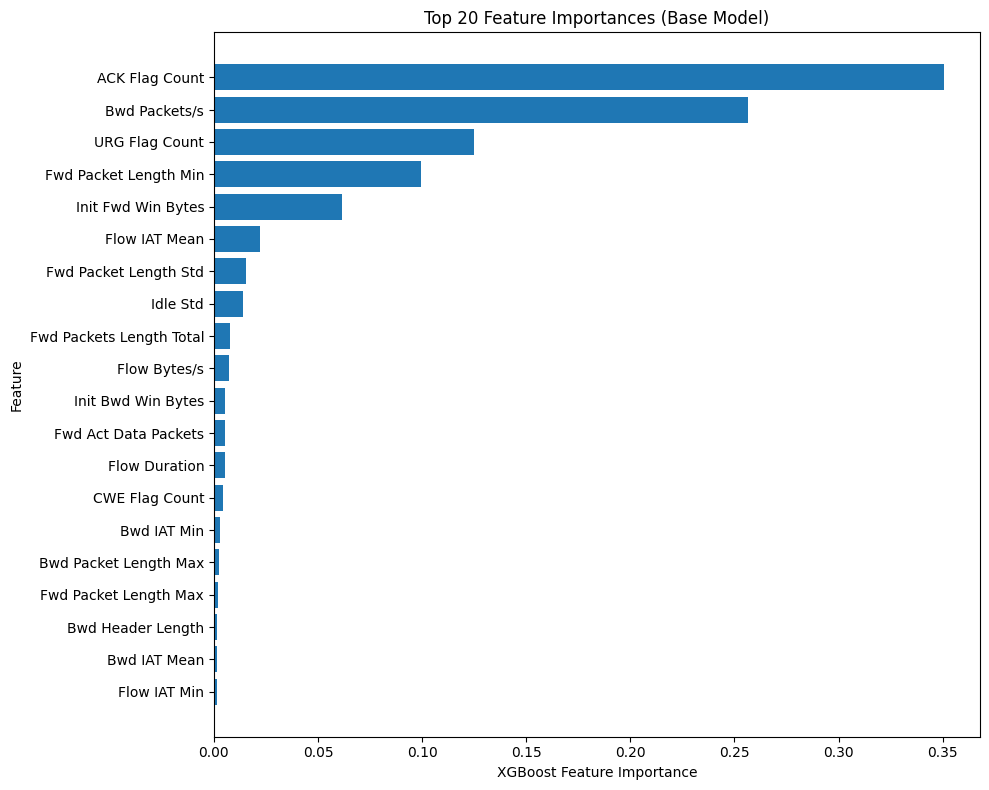

In [7]:
import os
import time  # Added for timing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA  # Added for PCA
from sklearn.inspection import permutation_importance  # Already imported, good for comparison if needed
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from xgboost import XGBClassifier

# --- Data Loading and Initial Preprocessing (Same as your code) ---

print("--- Data Loading and Initial Preprocessing ---")
dfps_train = []
dfps_test = []

# Make sure the directory path is correct for your environment
data_dir = "./cicddos2019/"
if not os.path.exists(data_dir):
    print(f"Warning: Data directory '{data_dir}' not found. Please ensure the CICDDoS2019 data is present.")
    # Example of how to handle missing data - adjust as needed
    # You might download it, point to a different path, or exit.
    exit()


for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith("-training.parquet"):
            dfp = os.path.join(dirname, filename)
            dfps_train.append(dfp)
            # print(f"Found training file: {dfp}") # Uncomment for debugging
        elif filename.endswith("-testing.parquet"):
            dfp = os.path.join(dirname, filename)
            dfps_test.append(dfp)
            # print(f"Found testing file: {dfp}") # Uncomment for debugging

if not dfps_train or not dfps_test:
    print("Error: No training or testing parquet files found in the specified directory.")
    exit()

# Common Prefixes in both lists
train_prefixes = [os.path.basename(dfp).split("-")[0] for dfp in dfps_train]
test_prefixes = [os.path.basename(dfp).split("-")[0] for dfp in dfps_test]

common_prefixes = list(set(train_prefixes).intersection(test_prefixes))
print(f"Common prefixes found: {common_prefixes}")

# Filter the dataframes to only include the common prefixes
dfps_train = [dfp for dfp in dfps_train if os.path.basename(dfp).split("-")[0] in common_prefixes]
dfps_test = [dfp for dfp in dfps_test if os.path.basename(dfp).split("-")[0] in common_prefixes]

if not dfps_train or not dfps_test:
    print("Error: No common files found after filtering by prefix.")
    exit()

print(f"Loading {len(dfps_train)} training files and {len(dfps_test)} testing files...")
train_df = pd.concat([pd.read_parquet(dfp) for dfp in dfps_train], ignore_index=True)
test_df = pd.concat([pd.read_parquet(dfp) for dfp in dfps_test], ignore_index=True)
print("Data loaded.")
print(f"Initial Training data shape: {train_df.shape}")
print(f"Initial Testing data shape: {test_df.shape}")


# Drop the WebDDoS class from the testing data (if it exists)
if "WebDDoS" in test_df["Label"].unique():
    test_df = test_df[test_df["Label"] != "WebDDoS"]
    print("Dropped 'WebDDoS' label from testing data.")

# Map the labels to the same format
label_mapping = {
    "DrDoS_UDP": "UDP",
    "UDP-lag": "UDPLag",
    "DrDoS_MSSQL": "MSSQL",
    "DrDoS_LDAP": "LDAP",
    "DrDoS_NetBIOS": "NetBIOS",
    "Syn": "Syn",
    "Benign": "Benign",
}
# Apply mapping only to labels present in the mapping dictionary
test_df["Label"] = test_df["Label"].map(lambda x: label_mapping.get(x, x))


# Drop specified labels
train_df = train_df[~train_df["Label"].isin(["NetBIOS", "UDPLag"])]
test_df = test_df[~test_df["Label"].isin(["NetBIOS", "UDPLag"])]
print("Dropped 'NetBIOS' and 'UDPLag' labels.")


# --- Feature Engineering & Further Preprocessing (Mostly same as your code) ---
print("\n--- Feature Engineering & Further Preprocessing ---")


# Define grab_col_names function (same as yours)
def grab_col_names(data, cat_th=10, car_th=20):
    cat_cols = [col for col in data.columns if data[col].dtypes == "O"]
    num_but_cat = [col for col in data.columns if data[col].nunique() < cat_th and data[col].dtypes != "O"]
    high_card_cat_cols = [col for col in data.columns if data[col].nunique() > car_th and data[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in high_card_cat_cols]
    num_cols = [col for col in data.columns if data[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]
    print(f"Observations: {data.shape[0]}")
    print(f"Variables: {data.shape[1]}")
    print(f"Categorical Columns: {len(cat_cols)}")
    print(f"Numerical Columns: {len(num_cols)}")
    print(f"High Cardinality Categorical Columns: {len(high_card_cat_cols)}")
    print(f"Number but Categorical Columns: {len(num_but_cat)}")
    return cat_cols, num_cols, high_card_cat_cols


# Drop columns with a single unique value before identifying column types
single_val_cols_train = [col for col in train_df.columns if train_df[col].nunique() <= 1]
single_val_cols_test = [col for col in test_df.columns if test_df[col].nunique() <= 1]
single_val_cols = list(set(single_val_cols_train) | set(single_val_cols_test))  # Combine unique columns from both

# Ensure 'Label' is not accidentally dropped if it becomes single-valued after filtering
if "Label" in single_val_cols:
    single_val_cols.remove("Label")

# Drop these columns if they exist in the dataframes
cols_to_drop_train = [col for col in single_val_cols if col in train_df.columns]
cols_to_drop_test = [col for col in single_val_cols if col in test_df.columns]

if cols_to_drop_train:
    train_df.drop(cols_to_drop_train, axis=1, inplace=True)
    print(f"Dropped {len(cols_to_drop_train)} single-value columns from train data: {cols_to_drop_train}")
if cols_to_drop_test:
    test_df.drop(cols_to_drop_test, axis=1, inplace=True)
    print(f"Dropped {len(cols_to_drop_test)} single-value columns from test data: {cols_to_drop_test}")


# Identify column types based on the potentially reduced training data
cat_cols, num_cols, high_card_cat_cols = grab_col_names(train_df.drop("Label", axis=1))  # Exclude label
print(f"Identified Categorical Columns: {cat_cols}")
print(f"Identified Numerical Columns: {num_cols}")
print(f"Identified High Cardinality Categorical Columns: {high_card_cat_cols}")


# Remove duplicate rows from training data
initial_train_rows = len(train_df)
train_df = train_df.drop_duplicates()
print(f"Removed {initial_train_rows - len(train_df)} duplicate rows from training data.")

# Remove highly correlated features (based on training data)
# Ensure only numeric columns present in the DataFrame are selected
numerical_cols_in_train = [col for col in num_cols if col in train_df.columns]
if numerical_cols_in_train:
    corr_matrix = train_df[numerical_cols_in_train].corr().abs()
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.8)]
    print(f"Found {len(high_corr_cols)} highly correlated columns (threshold > 0.8): {high_corr_cols}")

    # Drop these columns if they exist in both train and test dfs
    cols_to_drop_corr_train = [col for col in high_corr_cols if col in train_df.columns]
    cols_to_drop_corr_test = [col for col in high_corr_cols if col in test_df.columns]

    if cols_to_drop_corr_train:
        train_df.drop(cols_to_drop_corr_train, axis=1, inplace=True)
        print(f"Dropped {len(cols_to_drop_corr_train)} highly correlated columns from train data.")
    if cols_to_drop_corr_test:
        test_df.drop(cols_to_drop_corr_test, axis=1, inplace=True)
        print(f"Dropped {len(cols_to_drop_corr_test)} highly correlated columns from test data.")
else:
    print("No numerical columns found to calculate correlation.")
    high_corr_cols = []  # Ensure variable exists


# --- Data Splitting, Encoding, and Scaling (Base Model) ---
print("\n--- Preparing Data for Base Model ---")

# Align columns after all dropping steps - crucial!
train_cols = train_df.drop("Label", axis=1).columns
test_cols = test_df.drop("Label", axis=1).columns
common_features = list(set(train_cols) & set(test_cols))

print(f"Final features used ({len(common_features)}): {common_features}")

# Separate features (X) and target (y)
X = train_df[common_features]
y = train_df["Label"]
X_val_final = test_df[common_features]
y_val_final = test_df["Label"]

# Split the *training* data into train/test for model evaluation consistency
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,  # Added stratify
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Validation set shape: {X_val_final.shape}")

# Encode the target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
y_val_encoded = le.transform(y_val_final)  # Use the final validation set

# Label mapping for the target variable
label_map = {index: Label for index, Label in enumerate(le.classes_)}
print(f"Label mapping: {label_map}")

# Feature Scaling using MinMaxScaler
scaler_base = MinMaxScaler()
X_train_scaled = scaler_base.fit_transform(X_train)
X_test_scaled = scaler_base.transform(X_test)
X_val_scaled = scaler_base.transform(X_val_final)  # Use the final validation set

# --- Base Model Training & Evaluation ---
print("\n--- Training Base Model (All Selected Features) ---")
start_time = time.time()
model_base = XGBClassifier(
    eval_metric="mlogloss",  # Changed from logloss for multi-class
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,  # Recommended practice
    n_jobs=-1,  # Use all available CPU cores
)
model_base.fit(X_train_scaled, y_train_encoded)
end_time = time.time()
print(f"Base model training time: {end_time - start_time:.2f} seconds")


# Evaluate predictions
y_val_pred_base = model_base.predict(X_val_scaled)
y_test_pred_base = model_base.predict(X_test_scaled)


def evaluate_model(y_true, y_pred, prefix):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"{prefix} Accuracy: {accuracy:.4f}")
    print(f"{prefix} Precision: {precision:.4f}")
    print(f"{prefix} Recall: {recall:.4f}")
    print(f"{prefix} F1 Score: {f1:.4f}")
    return accuracy, precision, recall, f1


print("\n--- Base Model Performance ---")
print("Validation Set:")
val_metrics_base = evaluate_model(y_val_encoded, y_val_pred_base, "Val")
print("\nTest Set:")
test_metrics_base = evaluate_model(y_test_encoded, y_test_pred_base, "Test")

# --- Feature Importance & Top 5 Feature Selection ---
print("\n--- Feature Selection based on Importance ---")
feature_importances = model_base.feature_importances_
feature_names = X_train.columns  # Use columns from the original non-scaled X_train

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

N_TOP_FEATURES = 5
top_n_features = importance_df["Feature"].head(N_TOP_FEATURES).tolist()
print(f"Top {N_TOP_FEATURES} features based on XGBoost importance:")
print(importance_df.head(N_TOP_FEATURES))

# --- Prepare Data for Top 5 Feature Model ---
print(f"\n--- Preparing Data for Top {N_TOP_FEATURES} Feature Model ---")
X_train_top5 = X_train[top_n_features]
X_test_top5 = X_test[top_n_features]
X_val_top5 = X_val_final[top_n_features]  # Use the final validation set

# Scale the top 5 features - Fit scaler ONLY on training data
scaler_top5 = MinMaxScaler()
X_train_top5_scaled = scaler_top5.fit_transform(X_train_top5)
X_test_top5_scaled = scaler_top5.transform(X_test_top5)
X_val_top5_scaled = scaler_top5.transform(X_val_top5)

# --- Top 5 Feature Model Training & Evaluation ---
print(f"\n--- Training Top {N_TOP_FEATURES} Feature Model ---")
start_time = time.time()
model_top5 = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1,
)
# Use the same encoded labels as before
model_top5.fit(X_train_top5_scaled, y_train_encoded)
end_time = time.time()
print(f"Top {N_TOP_FEATURES} model training time: {end_time - start_time:.2f} seconds")


# Evaluate predictions
y_val_pred_top5 = model_top5.predict(X_val_top5_scaled)
y_test_pred_top5 = model_top5.predict(X_test_top5_scaled)

print(f"\n--- Top {N_TOP_FEATURES} Feature Model Performance ---")
print("Validation Set:")
val_metrics_top5 = evaluate_model(y_val_encoded, y_val_pred_top5, "Val")
print("\nTest Set:")
test_metrics_top5 = evaluate_model(y_test_encoded, y_test_pred_top5, "Test")

# --- Dimensionality Reduction using PCA ---
print("\n--- Dimensionality Reduction using PCA ---")
N_PCA_COMPONENTS = 2  # Let's use 5 for direct comparison, can be tuned
print(f"Applying PCA to reduce to {N_PCA_COMPONENTS} components...")

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=42)

# Fit PCA ONLY on the scaled training data (from the base model)
X_train_pca = pca.fit_transform(X_train_scaled)
# Transform test and validation sets using the *fitted* PCA
X_test_pca = pca.transform(X_test_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"Explained variance ratio by {N_PCA_COMPONENTS} components: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Shape after PCA - Train: {X_train_pca.shape}, Test: {X_test_pca.shape}, Val: {X_val_pca.shape}")


# --- PCA Model Training & Evaluation ---
print("\n--- Training PCA Model ---")
start_time = time.time()
model_pca = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1,
)
# Use the same encoded labels as before
model_pca.fit(X_train_pca, y_train_encoded)
end_time = time.time()
print(f"PCA model training time: {end_time - start_time:.2f} seconds")


# Evaluate predictions
y_val_pred_pca = model_pca.predict(X_val_pca)
y_test_pred_pca = model_pca.predict(X_test_pca)

print("\n--- PCA Model Performance ---")
print("Validation Set:")
val_metrics_pca = evaluate_model(y_val_encoded, y_val_pred_pca, "Val")
print("\nTest Set:")
test_metrics_pca = evaluate_model(y_test_encoded, y_test_pred_pca, "Test")

# --- Performance Comparison ---
print("\n--- === Performance Summary === ---")

results = {
    "Model": ["Base (All Features)", f"Top {N_TOP_FEATURES} Features", f"PCA ({N_PCA_COMPONENTS} Components)"],
    "Val Accuracy": [val_metrics_base[0], val_metrics_top5[0], val_metrics_pca[0]],
    "Val F1 Score": [val_metrics_base[3], val_metrics_top5[3], val_metrics_pca[3]],
    "Test Accuracy": [test_metrics_base[0], test_metrics_top5[0], test_metrics_pca[0]],
    "Test F1 Score": [test_metrics_base[3], test_metrics_top5[3], test_metrics_pca[3]],
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))  # Use to_string for better console formatting

# --- Optional: Plot Feature Importances ---
plt.figure(figsize=(10, 8))
plt.barh(importance_df["Feature"].head(20), importance_df["Importance"].head(20))  # Plot top 20
plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Base Model)")
plt.tight_layout()
plt.show()  # Uncomment to display plot

In [ ]:
# Import necessary libraries for MLP
from tensorflow import keras
from keras import layers, Input, Sequential, backend, optimizers, callbacks
from sklearn.preprocessing import OneHotEncoder
import numpy as np  # Ensure numpy is imported

print(f"\n--- Preparing Data for MLP (Top {N_TOP_FEATURES} Features) ---")

# 1. One-Hot Encode the labels
# Reshape labels to 2D array as OneHotEncoder expects
y_train_reshaped = y_train_encoded.reshape(-1, 1)
y_val_reshaped = y_val_encoded.reshape(-1, 1)
y_test_reshaped = y_test_encoded.reshape(-1, 1)

onehot_encoder = OneHotEncoder(
    sparse_output=False, handle_unknown="ignore"
)  # Changed sparse=False to sparse_output=False for newer sklearn versions

# Fit on training data and transform all sets
y_train_one_hot = onehot_encoder.fit_transform(y_train_reshaped)
y_val_one_hot = onehot_encoder.transform(y_val_reshaped)
y_test_one_hot = onehot_encoder.transform(y_test_reshaped)

num_classes = y_train_one_hot.shape[1]
print(f"Number of classes for MLP output: {num_classes}")
print("Labels successfully One-Hot Encoded.")
print(f"Training labels shape: {y_train_one_hot.shape}")
print(f"Validation labels shape: {y_val_one_hot.shape}")
print(f"Test labels shape: {y_test_one_hot.shape}")


# 2. Define the MLP Model Architecture
print("\n--- Defining MLP Model ---")

# Clear previous Keras session if any (good practice)
backend.clear_session()

mlp_model = Sequential(
    [
        Input(shape=(N_TOP_FEATURES,), name="input_layer"),
        layers.Dense(64, activation="elu", name="hidden_layer_1"),
        layers.Dropout(0.3, name="dropout_1"),  # Added Dropout for regularization
        layers.Dense(32, activation="elu", name="hidden_layer_2"),
        layers.Dropout(0.3, name="dropout_2"),  # Added Dropout
        layers.Dense(num_classes, activation="softmax", name="output_layer"),
    ]
)

mlp_model.summary()

# 3. Compile the Model
print("\n--- Compiling MLP Model ---")
mlp_model.compile(
    loss="categorical_crossentropy",  # Use for one-hot encoded labels
    optimizer=optimizers.Adam(learning_rate=0.001),  # Adam optimizer with default lr often works well
    metrics=["accuracy"],
)

# 4. Define Callbacks (Early Stopping)
print("\n--- Setting up Callbacks ---")
early_stopping = callbacks.EarlyStopping(
    monitor="val_accuracy",  # Monitor validation accuracy
    patience=10,  # Stop after 10 epochs with no improvement
    restore_best_weights=True,  # Restore weights from the epoch with best val_accuracy
    verbose=1,
)

# 5. Train the Model
print("\n--- Training MLP Model ---")
EPOCHS = 100  # Set a higher number of epochs, early stopping will handle overfitting
BATCH_SIZE = 64

start_time = time.time()  # Reuse start_time variable

history = mlp_model.fit(
    X_train_top5_scaled,
    y_train_one_hot,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_top5_scaled, y_val_one_hot),
    callbacks=[early_stopping],  # Add the early stopping callback
    verbose=1,  # Set to 1 or 2 for progress updates, 0 for silent
)

end_time = time.time()
print(f"MLP model training time: {end_time - start_time:.2f} seconds")


# 6. Evaluate the Model
print("\n--- MLP Model Performance ---")

# Evaluate on validation set
loss_val, accuracy_val = mlp_model.evaluate(X_val_top5_scaled, y_val_one_hot, verbose=0)
print(f"Validation Loss: {loss_val:.4f}")
print(f"Validation Accuracy: {accuracy_val:.4f}")

# Evaluate on test set
loss_test, accuracy_test = mlp_model.evaluate(X_test_top5_scaled, y_test_one_hot, verbose=0)
print(f"Test Loss: {loss_test:.4f}")
print(f"Test Accuracy: {accuracy_test:.4f}")

# Get predictions to calculate other metrics (Precision, Recall, F1)
y_val_pred_proba_mlp = mlp_model.predict(X_val_top5_scaled)
y_test_pred_proba_mlp = mlp_model.predict(X_test_top5_scaled)

# Convert probabilities to class labels
y_val_pred_mlp = np.argmax(y_val_pred_proba_mlp, axis=1)
y_test_pred_mlp = np.argmax(y_test_pred_proba_mlp, axis=1)

# Use the evaluate_model function defined earlier (make sure it's available)
# Remember: the evaluate_model function expects the original encoded labels (not one-hot)
print("\nDetailed Validation Set Metrics (MLP):")
val_metrics_mlp = evaluate_model(y_val_encoded, y_val_pred_mlp, "Val")  # Use original y_val_encoded
print("\nDetailed Test Set Metrics (MLP):")
test_metrics_mlp = evaluate_model(y_test_encoded, y_test_pred_mlp, "Test")  # Use original y_test_encoded


# --- Comparison with Top 5 XGBoost ---
print("\n--- === Performance Summary (Top 5 Features) === ---")

# Fetching previous XGBoost Top 5 results for comparison
# Ensure val_metrics_top5 and test_metrics_top5 variables from the previous run are accessible
# If not, you might need to re-run that part or hardcode the values based on previous output
try:
    xgb_val_acc = val_metrics_top5[0]
    xgb_val_f1 = val_metrics_top5[3]
    xgb_test_acc = test_metrics_top5[0]
    xgb_test_f1 = test_metrics_top5[3]
except NameError:
    print("Warning: Previous XGBoost top-5 metrics not found in current session. Using placeholder values.")
    # Placeholder values based on your previous message (adjust if needed)
    xgb_val_acc = 0.9710
    xgb_val_f1 = -1  # F1 wasn't mentioned, using placeholder
    xgb_test_acc = -1  # Test metrics weren't mentioned, using placeholder
    xgb_test_f1 = -1  # Test metrics weren't mentioned, using placeholder


results_top5_compare = {
    "Model": [f"XGBoost (Top {N_TOP_FEATURES})", f"MLP (Top {N_TOP_FEATURES})"],
    "Val Accuracy": [xgb_val_acc, val_metrics_mlp[0]],
    "Val F1 Score": [xgb_val_f1, val_metrics_mlp[3]],
    "Test Accuracy": [xgb_test_acc, test_metrics_mlp[0]],
    "Test F1 Score": [xgb_test_f1, test_metrics_mlp[3]],
}

results_top5_compare_df = pd.DataFrame(results_top5_compare)
print(results_top5_compare_df.to_string(index=False))

# Optional: Plot training history

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MLP Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MLP Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()  # Uncomment to display plot


--- Preparing Data for MLP (Top 5 Features) ---
Number of classes for MLP output: 5
Labels successfully One-Hot Encoded.
Training labels shape: (93072, 5)
Validation labels shape: (29452, 5)
Test labels shape: (23268, 5)

--- Defining MLP Model ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,629 (10.27 KB)

 Trainable params: 2,629 (10.27 KB)

 Non-trainable params: 0 (0.00 B)


--- Compiling MLP Model ---

--- Setting up Callbacks ---

--- Training MLP Model ---
Epoch 1/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.7959 - loss: 0.5650 - val_accuracy: 0.9490 - val_loss: 0.1650
Epoch 2/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9727 - loss: 0.1447 - val_accuracy: 0.9602 - val_loss: 0.1482
Epoch 3/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.9780 - loss: 0.1126 - val_accuracy: 0.9678 - val_loss: 0.1463
Epoch 4/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.9792 - loss: 0.1024 - val_accuracy: 0.9667 - val_loss: 0.1399
Epoch 5/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9811 - loss: 0.0899 - val_accuracy: 0.9568 - val_loss: 0.1403
Epoch 6/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.9799 - loss: 0.0867 - val_accuracy: 0.9662 - val_loss: 0.1478
Epoch 7/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.9809 - loss: 0.0790 - val_accuracy: 0.9684 -